# DSPy GEPA prompt optimization (text classification)

This notebook mirrors `03_Advanced_DSPy_Optimizer_GEPA.py` and walks through using the **GEPA** optimizer to improve a smaller Gemini model on a supervised text-classification task. It is adapted from the [Mosaic AI Databricks GEPA post](https://medium.com/@AI-on-Databricks/prompt-optimizing-with-gepa-and-databricks-for-90x-cheaper-inference-0068a2909d86) but stripped of any Databricks dependency.

**Flow**

1. **Dataset setup** — load the PubMed text-classification dataset (previously downloaded to `./dataset/`) and build balanced train/test splits.
2. **DSPy signature + module** — define `TextClassificationSignature` and `TextClassifier` (Gemini via LiteLLM).
3. **Evaluation metric** — exact-match score with feedback strings GEPA can read.
4. **Baseline** — measure uncompiled small and large Gemini accuracy.
5. **GEPA configuration + training** — compile the student using the large Gemini as the reflection LM.
6. **Testing** — re-evaluate the compiled student, print absolute/relative lift, inspect the evolved prompt.

**Prerequisites**

- `GOOGLE_API_KEY` in `.env` at the repo root (auto-loaded by `python-dotenv`).
- Dataset files on disk — run once from the repo root:
  ```bash
  python dspy_hackathon/download_pubmed_dataset.py
  ```
  This creates `dspy_hackathon/dataset/train.csv` and `dspy_hackathon/dataset/test.csv`.

## Install dependencies

Run once (uncomment the cell below) and restart the kernel. `certifi` fixes `SSL: CERTIFICATE_VERIFY_FAILED` on some macOS Python builds.

In [1]:
# %pip install --upgrade dspy mlflow python-dotenv certifi pandas numpy pyyaml matplotlib tqdm

## 1. Imports

In [2]:
import dataclasses
import io
import json
import os
import ssl
import urllib.request
from pathlib import Path

import certifi
import numpy as np
import pandas as pd
import yaml
from dotenv import load_dotenv
from dspy.datasets.dataset import Dataset
from pandas import StringDtype

/Users/aurobindotripathy/goog-agents-jumpstart/venv/lib/python3.14/site-packages/opik/rest_api/core/pydantic_utilities.py:13: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.datetime_parse import parse_date as parse_date


## Configuration

All knobs live in `gepa-config.yaml` (next to this notebook) so reruns stay reproducible:

- **`models.small`** — the student we want to optimize (cheap / fast).
- **`models.large`** — stronger baseline used as an upper bound.
- **`models.reflection`** — the teacher LM GEPA uses to propose new prompts; falls back to `models.large` when null/omitted.
- **`dataset.training_samples_per_label`** — per-class train sample size (drawn from `train.csv`).
- **`dataset.val_samples_per_label`** — per-class validation sample size, drawn from `train.csv` **disjoint from the train sample**. Passed to `gepa.compile(..., valset=val_dataset)` so GEPA's Pareto bookkeeping uses held-out data instead of overfitting to the train sample.
- **`dataset.test_samples_per_label`** — per-class test sample size (drawn from `test.csv`).
- **`gepa.auto`** — preset budget (`"light" | "medium" | "heavy"`) controlling total metric calls.
- **`gepa.reflection_minibatch_size`** — examples shown to the reflection LM per rewrite proposal; `null` → defaults to `len(train_dataset)`.
- **`gepa.reflection_lm_max_tokens`** — token budget for each reflection-LM (teacher) call.
- **`gepa.num_threads`** / **`gepa.seed`** / **`gepa.track_stats`** — parallelism, RNG seed, and whether `compiled_gepa.detailed_results` (Pareto-plot data) is populated.

`load_dotenv()` walks up from the current working directory, so running the notebook from the repo root or from `dspy_hackathon/` both work.

In [3]:
load_dotenv()  # looks in cwd and parents for .env


def _load_gepa_config(filename: str = "gepa-config.yaml") -> dict:
    """Find and parse the YAML config; works from repo root or from dspy_hackathon/."""
    candidates = [Path(filename), Path("dspy_hackathon") / filename]
    for p in candidates:
        if p.exists():
            print(f"Loading config from: {p}")
            with p.open() as f:
                return yaml.safe_load(f) or {}
    raise FileNotFoundError(f"Config file not found in {candidates}")


_config = _load_gepa_config()
_models = _config.get("models", {})
_dataset_cfg = _config.get("dataset", {})
_gepa_cfg = _config.get("gepa", {})

# Gemini model ids (LiteLLM). Student = smaller; large = stronger baseline; reflection = GEPA teacher LM.
small_model = _models["small"]
large_model = _models["large"]
reflection_model = _models.get("reflection") or large_model

training_samples_per_label = int(_dataset_cfg["training_samples_per_label"])
val_samples_per_label = int(_dataset_cfg["val_samples_per_label"])
test_samples_per_label = int(_dataset_cfg["test_samples_per_label"])

# GEPA optimizer knobs. `reflection_minibatch_size=None` → use len(train_dataset) at construction time.
config_auto = _gepa_cfg.get("auto", "light")
config_reflection_minibatch_size = _gepa_cfg.get("reflection_minibatch_size")
config_reflection_lm_max_tokens = int(_gepa_cfg.get("reflection_lm_max_tokens", 100000))
config_num_threads = int(_gepa_cfg.get("num_threads", 16))
config_seed = int(_gepa_cfg.get("seed", 1))
config_track_stats = bool(_gepa_cfg.get("track_stats", True))

print(f"small_model                    = {small_model}")
print(f"large_model                    = {large_model}")
print(f"reflection_model               = {reflection_model}")
print(f"training_samples_per_label     = {training_samples_per_label}")
print(f"val_samples_per_label          = {val_samples_per_label}")
print(f"test_samples_per_label         = {test_samples_per_label}")
print(f"gepa.auto                      = {config_auto}")
print(f"gepa.reflection_minibatch_size = {config_reflection_minibatch_size}  (None -> len(train_dataset))")
print(f"gepa.reflection_lm_max_tokens  = {config_reflection_lm_max_tokens}")
print(f"gepa.num_threads               = {config_num_threads}")
print(f"gepa.seed                      = {config_seed}")
print(f"gepa.track_stats               = {config_track_stats}")
print(f"GOOGLE_API_KEY set: {bool(os.environ.get('GOOGLE_API_KEY'))}")

Loading config from: gepa-config.yaml
small_model                = gemini/gemini-2.5-flash-lite
large_model                = gemini/gemini-3.1-pro-preview
reflection_model           = gemini/gemini-3.1-pro-preview
training_samples_per_label = 3
val_samples_per_label      = 3
test_samples_per_label     = 10
GOOGLE_API_KEY set: True


## 2. Dataset setup

We read the PubMed train/test CSVs from a local `dataset/` folder. If you run this notebook from the repo root, the files live at `./dspy_hackathon/dataset/`; if you launch Jupyter from inside `dspy_hackathon/`, they live at `./dataset/`. The helper below tries both.

**Labels:** `CONCLUSIONS`, `RESULTS`, `METHODS`, `OBJECTIVE`, `BACKGROUND`.

In [4]:
def _to_json_serializable(obj):
    """Recursively convert LM history to JSON-safe data (e.g. LiteLLM ModelResponse objects)."""
    if obj is None or isinstance(obj, (bool, int, float, str)):
        return obj
    if isinstance(obj, dict):
        return {str(k): _to_json_serializable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_json_serializable(x) for x in obj]
    if isinstance(obj, set):
        return [_to_json_serializable(x) for x in sorted(obj, key=str)]
    model_dump = getattr(obj, "model_dump", None)
    if callable(model_dump):
        try:
            return _to_json_serializable(model_dump())
        except Exception:
            pass
    dict_fn = getattr(obj, "dict", None)
    if callable(dict_fn):
        try:
            return _to_json_serializable(dict_fn())
        except Exception:
            pass
    if dataclasses.is_dataclass(obj) and not isinstance(obj, type):
        try:
            return _to_json_serializable(dataclasses.asdict(obj))
        except Exception:
            pass
    return str(obj)


def _read_csv_from_url(url: str) -> pd.DataFrame:
    """Fallback: load a CSV over HTTPS using certifi's CA bundle."""
    print(f"Reading CSV from URL: {url}")
    ctx = ssl.create_default_context(cafile=certifi.where())
    with urllib.request.urlopen(url, context=ctx, timeout=120) as resp:
        return pd.read_csv(io.BytesIO(resp.read()))


def _read_csv_from_disk(filename: str, dataset_dir: str | None = None) -> pd.DataFrame:
    """Load a CSV from a local dataset directory; checks both `./dataset` and `./dspy_hackathon/dataset`."""
    candidates = [dataset_dir] if dataset_dir else ["./dataset", "./dspy_hackathon/dataset"]
    for d in candidates:
        p = Path(d) / filename
        if p.exists():
            print(f"Reading CSV from disk: {p}")
            return pd.read_csv(p)
    raise FileNotFoundError(
        f"CSV '{filename}' not found in {candidates}. "
        f"Run `python dspy_hackathon/download_pubmed_dataset.py` to download first."
    )


def read_data_and_subset_to_categories() -> tuple[pd.DataFrame, pd.DataFrame]:
    """Load the PubMed train/test CSVs from disk and drop the unused `description_cln` column."""
    train = _read_csv_from_disk("train.csv")
    test = _read_csv_from_disk("test.csv")
    train.drop("description_cln", axis=1, inplace=True)
    test.drop("description_cln", axis=1, inplace=True)
    return train, test

In [5]:
class CSVDataset(Dataset):
    """Balanced sampler: per-class `n_train` + `n_val` (both from train.csv, disjoint) + `n_test` (from test.csv)."""

    def __init__(
        self,
        n_train_per_label: int = 40,
        n_val_per_label: int = 0,
        n_test_per_label: int = 20,
        *args,
        **kwargs,
    ) -> None:
        super().__init__(*args, **kwargs)
        self.n_train_per_label = n_train_per_label
        self.n_val_per_label = n_val_per_label
        self.n_test_per_label = n_test_per_label
        self._create_train_val_test_split_and_ensure_labels()

    def _create_train_val_test_split_and_ensure_labels(self) -> None:
        """Sample disjoint per-class train/val from train.csv, and per-class test from test.csv."""
        train_df, test_df = read_data_and_subset_to_categories()
        train_df = train_df.astype(StringDtype())
        test_df = test_df.astype(StringDtype())

        train_samples_df = pd.concat(
            [group.sample(n=self.n_train_per_label, random_state=1) for _, group in train_df.groupby("target")]
        )

        # Val is sampled from train.csv but disjoint from the train sample so the two splits never overlap.
        if self.n_val_per_label > 0:
            remaining_train_df = train_df.drop(train_samples_df.index)
            val_samples_df = pd.concat(
                [group.sample(n=self.n_val_per_label, random_state=2) for _, group in remaining_train_df.groupby("target")]
            )
            self._dev = val_samples_df.to_dict(orient="records")
        else:
            self._dev = []

        test_samples_df = pd.concat(
            [group.sample(n=self.n_test_per_label, random_state=1) for _, group in test_df.groupby("target")]
        )

        self._train = train_samples_df.to_dict(orient="records")
        self._test = test_samples_df.to_dict(orient="records")

In [6]:
# Small splits to keep the demo fast and cheap.
dataset = CSVDataset(
    n_train_per_label=training_samples_per_label,
    n_val_per_label=val_samples_per_label,
    n_test_per_label=test_samples_per_label,
)

train_dataset = [example.with_inputs("description") for example in dataset.train]
val_dataset = [example.with_inputs("description") for example in dataset.dev]
test_dataset = [example.with_inputs("description") for example in dataset.test]

print(f"train dataset size: {len(train_dataset)}")
print(f"val   dataset size: {len(val_dataset)}")
print(f"test  dataset size: {len(test_dataset)}")
print(f"Train labels:       {sorted(set(ex.target for ex in dataset.train))}")

# Sanity: train and val are disjoint by construction (sampled from disjoint index sets), but check anyway.
_train_descs = {ex["description"] for ex in train_dataset}
_val_descs = {ex["description"] for ex in val_dataset}
_overlap = _train_descs & _val_descs
print(f"train/val description overlap: {len(_overlap)} (expected 0)")

print("\n********* train dataset sample entries (first 5) *********")
for ex in train_dataset[:5]:
    print(ex)
print("\n********* val dataset sample entries (first 5) *********")
for ex in val_dataset[:5]:
    print(ex)
print("\n********* test dataset sample entries (first 5) *********")
for ex in test_dataset[:5]:
    print(ex)

Reading CSV from disk: dataset/train.csv
Reading CSV from disk: dataset/test.csv
train dataset size: 15
val   dataset size: 15
test  dataset size: 50
Train labels:       ['BACKGROUND', 'CONCLUSIONS', 'METHODS', 'OBJECTIVE', 'RESULTS']
train/val description overlap: 0 (expected 0)

********* train dataset sample entries (first 5) *********
Example({'target': 'BACKGROUND', 'description': 'Although opioids are effective treatments for postoperative pain , they contribute to the delayed recovery of gastrointestinal function .'}) (input_keys={'description'})
Example({'target': 'OBJECTIVE', 'description': 'This study evaluated whether increased exercise in hospital and afterward would shorten length of stay and improve physical function at 1 month .'}) (input_keys={'description'})
Example({'target': 'OBJECTIVE', 'description': 'There is a need to identify effective interventions to promote walking capacity in seniors .'}) (input_keys={'description'})
Example({'target': 'CONCLUSIONS', 'descri

In [7]:
from typing import Literal
import warnings

import dspy

# Opik (imported transitively by mlflow) warns about Pydantic v1 on Python 3.14+; silence it.
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=r".*Pydantic V1 functionality isn't compatible with Python 3\.\d+.*",
)
import mlflow


def gemini_llm(model: str, cache: bool = False, **kwargs) -> dspy.LM:
    return dspy.LM(model, api_key=os.environ["GOOGLE_API_KEY"], cache=cache, **kwargs)


mlflow.dspy.autolog(log_evals=True, log_compiles=True, log_traces_from_compile=True)

/Users/aurobindotripathy/goog-agents-jumpstart/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. DSPy signature and classifier module

- **`TextClassificationSignature`** — typed I/O contract for one LM call. `target` is constrained to the 5 label strings (structured output).
- **`TextClassifier`** — a `dspy.Module` that wraps `dspy.Predict(TextClassificationSignature)` and pins the chosen Gemini model.

MLflow autologging is turned on so compile/eval traces are captured if you browse `mlflow ui`.

In [8]:
class TextClassificationSignature(dspy.Signature):
    description: str = dspy.InputField()
    target: Literal["CONCLUSIONS", "RESULTS", "METHODS", "OBJECTIVE", "BACKGROUND"] = dspy.OutputField()


class TextClassifier(dspy.Module):
    """Classifies medical-text fragments into one of five PubMed structural categories."""

    def __init__(self, model: str):
        super().__init__()
        self.lm = gemini_llm(model, cache=False, max_tokens=25000)
        self.generate_classification = dspy.Predict(TextClassificationSignature)

    def forward(self, description: str):
        with dspy.context(lm=self.lm):
            return self.generate_classification(description=description)

### Sanity check

In [9]:
# Smoke test: run the student on one made-up description.
text_classifier = TextClassifier(model=small_model)
description = (
    "This study is designed as a randomised controlled trial in which men living with HIV in Australia "
    "will be assigned to either an intervention group or usual care control group ."
)
print(f"Using {small_model} to classify:\n{description}\n")
print(text_classifier(description=description))

# now run the smoke test on the large model
text_classifier_large = TextClassifier(model=large_model)
print(f"Using {large_model} to classify:\n{description}\n")
print(text_classifier_large(description=description))

Using gemini/gemini-2.5-flash-lite to classify:
This study is designed as a randomised controlled trial in which men living with HIV in Australia will be assigned to either an intervention group or usual care control group .

Prediction(
    target='METHODS'
)
Using gemini/gemini-3.1-pro-preview to classify:
This study is designed as a randomised controlled trial in which men living with HIV in Australia will be assigned to either an intervention group or usual care control group .

Prediction(
    target='METHODS'
)


## 4. Evaluation metric

GEPA expects a metric that returns a `dspy.Prediction` with a numeric `score` and a text `feedback`. Feedback is the signal GEPA's reflection LM reads when it proposes prompt rewrites.

In [10]:
from tqdm.auto import tqdm


def validate_classification_with_feedback(example, prediction, trace=None, pred_name=None, pred_trace=None):
    """Score 1 if predicted label matches gold, else 0; feedback string helps GEPA refine prompts."""
    if example.target == prediction.target:
        return dspy.Prediction(score=1, feedback="Correct: prediction matches the gold label.")
    return dspy.Prediction(
        score=0,
        feedback=f"Incorrect: expected '{example.target}' but model predicted '{prediction.target}'.",
    )


def check_accuracy_on_test_dataset(classifier, test_data=test_dataset, desc: str = "Evaluating") -> float:
    """Run the classifier across `test_data` and return mean exact-match accuracy."""
    scores = []
    progress = tqdm(test_data, desc=desc, unit="ex")
    for example in progress:
        prediction = classifier(description=example["description"])
        scores.append(validate_classification_with_feedback(example, prediction).score)
        progress.set_postfix(acc=f"{np.mean(scores):.3f}")
    return float(np.mean(scores))

## 5. Baseline: small vs. large Gemini (before GEPA)

Before optimizing, we capture:

- The **original prompt** DSPy generates from `TextClassificationSignature` for the student (by running one forward pass and peeking at `lm.history`).
- The **uncompiled student accuracy** and the **large-model accuracy** on the 50-example test set (our ceiling reference).

In [11]:
baseline_classifier = TextClassifier(model=small_model)
_ = baseline_classifier(description=description)
original_prompt = baseline_classifier.lm.history[-1]["messages"][0]["content"]
print(f"=== Original (pre-GEPA) prompt for {small_model} ===\n")
print(original_prompt)

=== Original (pre-GEPA) prompt for gemini/gemini-2.5-flash-lite ===

Your input fields are:
1. `description` (str):
Your output fields are:
1. `target` (Literal['CONCLUSIONS', 'RESULTS', 'METHODS', 'OBJECTIVE', 'BACKGROUND']):
All interactions will be structured in the following way, with the appropriate values filled in.

[[ ## description ## ]]
{description}

[[ ## target ## ]]
{target}        # note: the value you produce must exactly match (no extra characters) one of: CONCLUSIONS; RESULTS; METHODS; OBJECTIVE; BACKGROUND

[[ ## completed ## ]]
In adhering to this structure, your objective is: 
        Given the fields `description`, produce the fields `target`.


In [12]:
uncompiled_small_lm_accuracy = check_accuracy_on_test_dataset(
    TextClassifier(model=small_model), desc=f"Uncompiled {small_model}"
)
print(f"Uncompiled {small_model} accuracy on test dataset: {uncompiled_small_lm_accuracy:.4f}")


uncompiled_large_lm_accuracy = check_accuracy_on_test_dataset(
    TextClassifier(model=large_model), desc=f"Uncompiled {large_model}"
)
print(f"Uncompiled {large_model} accuracy on test dataset: {uncompiled_large_lm_accuracy:.4f}")

Uncompiled gemini/gemini-2.5-flash-lite: 100%|██████████| 50/50 [00:50<00:00,  1.01s/ex, acc=0.660]


Uncompiled gemini/gemini-2.5-flash-lite accuracy on test dataset: 0.6600


Uncompiled gemini/gemini-3.1-pro-preview: 100%|██████████| 50/50 [01:52<00:00,  2.25s/ex, acc=0.860]

Uncompiled gemini/gemini-3.1-pro-preview accuracy on test dataset: 0.8600


## 6. GEPA configuration

All knobs except the metric and the runtime-derived `reflection_minibatch_size` come from the `gepa:` section of `gepa-config.yaml` (loaded into the `config_*` variables in section 1).

- **`metric=`** — `validate_classification_with_feedback` above; returns `score + feedback`.
- **`auto=config_auto`** — pre-set budget; DSPy will print something like *"Running GEPA for approx 440 metric calls / 29.33 full evals on the train set."*
- **`reflection_minibatch_size`** — examples shown to the reflection LM per rewrite proposal. If unset in YAML (`null`), we default to `len(train_dataset)`.
- **`reflection_lm=`** — the larger Gemini (`reflection_model`), the "teacher" that rewrites instructions; token budget per call is `config_reflection_lm_max_tokens`.
- **`num_threads`, `seed`, `track_stats`** — parallelism, reproducibility, and whether `compiled_gepa.detailed_results` (the Pareto-plot data) is populated.

`gepa.compile(...)` below is invoked with **both** `trainset` (for prompt evolution) and `valset=val_dataset` (for Pareto-frontier bookkeeping and best-candidate selection). The val split is sampled from `train.csv` but disjoint from the train sample, so GEPA's "best so far" decisions are made on examples it never optimized against.

In [13]:
import uuid

run_id = str(uuid.uuid4())
print(f"run_id: {run_id}")

_reflection_minibatch_size = (
    config_reflection_minibatch_size
    if config_reflection_minibatch_size is not None
    else len(train_dataset)
)

gepa = dspy.GEPA(
    metric=validate_classification_with_feedback,
    auto=config_auto,
    reflection_minibatch_size=_reflection_minibatch_size,
    reflection_lm=gemini_llm(reflection_model, max_tokens=config_reflection_lm_max_tokens),
    num_threads=config_num_threads,
    seed=config_seed,
    track_stats=config_track_stats,
)

run_id: 413c6767-abfe-4f6a-a746-416d65d273ab


## 7. Training: run GEPA (compile)

`gepa.compile(...)` runs the optimization loop: evaluate candidates on the trainset, let the reflection LM propose prompt rewrites, keep the Pareto front, repeat until the budget is exhausted. The resulting program is saved to JSON so we can reload it later.

This cell does real API traffic to both `small_model` (many times) and `reflection_model` (a handful of times). Expect minutes, not seconds.

In [14]:
import threading
from tqdm.auto import tqdm

print("Starting GEPA optimization...")

# Wrap GEPA's metric so we can drive a tqdm bar from each scoring call.
# `max_metric_calls` is the budget DSPy computes from `auto="light"`.
_orig_metric = gepa.metric_fn
_progress = tqdm(total=gepa.max_metric_calls, desc="GEPA metric calls", unit="call")
_correct = 0
_progress_lock = threading.Lock()  # GEPA uses num_threads>1; guard the shared counters.


def _metric_with_progress(example, prediction, trace=None, pred_name=None, pred_trace=None):
    global _correct
    result = _orig_metric(example, prediction, trace, pred_name, pred_trace)
    score = int(getattr(result, "score", 0) or 0)
    with _progress_lock:
        _correct += score
        _progress.update(1)
        _progress.set_postfix(acc=f"{_correct / _progress.n:.3f}")
    return result


gepa.metric_fn = _metric_with_progress

try:
    with mlflow.start_run(run_name=f"gepa_{run_id}"):
        compiled_gepa = gepa.compile(
            TextClassifier(model=small_model),
            trainset=train_dataset,  # used for prompt evolution
            valset=val_dataset,  # used for Pareto bookkeeping / best-candidate selection
        )
finally:
    _progress.close()
    gepa.metric_fn = _orig_metric

compiled_path = f"compiled_gepa_{run_id}.json"
compiled_gepa.save(compiled_path)
print(f"GEPA optimization completed. Saved: {compiled_path}")

Starting GEPA optimization...


GEPA metric calls: 0call [00:00, ?call/s]2026/04/25 16:10:01 INFO dspy.teleprompt.gepa.gepa: Running GEPA for approx 440 metric calls of the program. This amounts to 14.67 full evals on the train+val set.
2026/04/25 16:10:01 INFO dspy.teleprompt.gepa.gepa: Using 15 examples for tracking Pareto scores. You can consider using a smaller sample of the valset to allow GEPA to explore more diverse solutions within the same budget. GEPA requires you to provide the smallest valset that is just large enough to match your downstream task distribution, while providing as large trainset as possible.
GEPA metric calls: 15call [00:00, 21.13call/s, acc=0.733]2026/04/25 16:10:01 INFO dspy.evaluate.evaluate: Average Metric: 11.0 / 15 (73.3%)
2026/04/25 16:10:02 INFO dspy.teleprompt.gepa.gepa: Iteration 0: Base program full valset score: 0.7333333333333333 over 15 / 15 examples
2026/04/25 16:10:02 INFO dspy.teleprompt.gepa.gepa: Iteration 1: Selected program 0 score: 0.7333333333333333


  0%|          | 0/15 [00:00<?, ?it/s]

GEPA metric calls: 16call [00:01, 21.13call/s, acc=0.750]

Average Metric: 1.00 / 1 (100.0%):   7%|▋         | 1/15 [00:00<00:06,  2.04it/s]

...

GEPA metric calls: 540call [01:41,  5.11call/s, acc=0.911]

Average Metric: 14.00 / 15 (93.3%): 100%|██████████| 15/15 [00:02<00:00,  5.14it/s]

2026/04/25 16:11:42 INFO dspy.evaluate.evaluate: Average Metric: 14.0 / 15 (93.3%)
GEPA metric calls: 555call [01:41,  5.09call/s, acc=0.912]

2026/04/25 16:11:50 INFO dspy.teleprompt.gepa.gepa: Iteration 14: Proposed new text for generate_classification: Your task is to classify a given sentence (`description`) from a medical or scientific abstract into one of the following five rhetorical categories: BACKGROUND, OBJECTIVE, METHODS, RESULTS, or CONCLUSIONS. 

Output the category name exactly in the `target` field.

### Guidelines for Classification:

- **BACKGROUND**: Provides context, states the background problem, or describes the overarching aim or design of the study. General factual statements about a disease or treatment fall here.
  *Crucial Edge Case*: Sentences explicitly stating "The aim of the study was to..." or "This clinical study was designed to assess..." must be classified as **BACKGROUND**, not OBJECTIVE. Even though they sound like goals, they are structural background statements in certain abstract formats.

- **OBJECTIVE**: Explicitly states the specific goals, hypotheses, or purposes of the study (e.g.,

GEPA optimization completed. Saved: compiled_gepa_413c6767-abfe-4f6a-a746-416d65d273ab.json


## 7b. Visualize GEPA progress and the Pareto frontier

With `track_stats=True`, `compiled_gepa.detailed_results` (a `DspyGEPAResult`) holds the full search history. We plot two things:

- **Progress curve** — running best aggregate val-set score as cumulative metric calls grow. Shows how quickly GEPA finds improvements and where it plateaus.
- **Pareto frontier** — every proposed candidate as a point at *(metric calls when proposed, aggregate val score)*. Candidates in the Pareto-optimal set (best on at least one val task — i.e. in the union of `per_val_instance_best_candidates`) are highlighted; the others are dominated.

Candidates proposed:     9
Pareto-optimal set size: 9
Best aggregate score:    0.8667 (candidate #1)
Total metric calls:      465


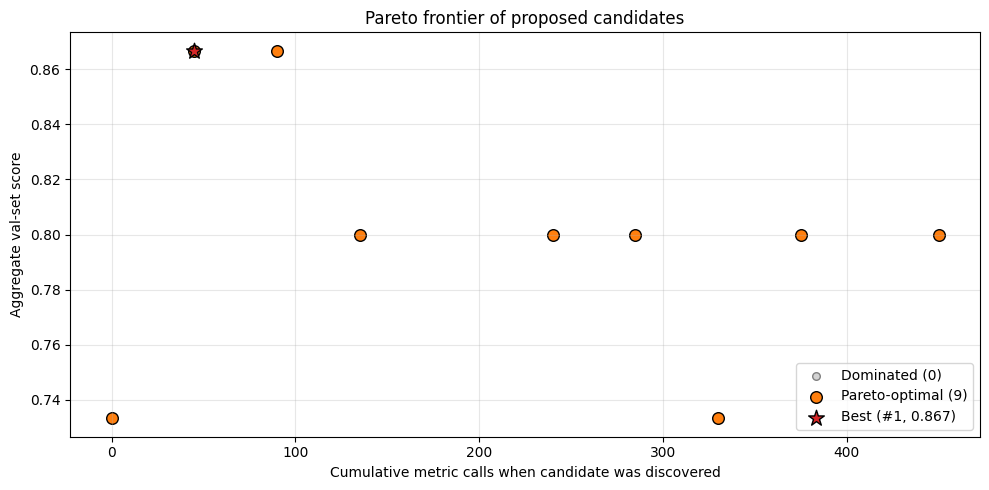

In [15]:
import matplotlib.pyplot as plt

results = getattr(compiled_gepa, "detailed_results", None)
if results is None:
    raise RuntimeError(
        "compiled_gepa.detailed_results is missing. Re-run cell 22 with `track_stats=True` "
        "and re-compile so the search history is captured."
    )

scores = list(results.val_aggregate_scores)
budget = list(results.discovery_eval_counts)
n_candidates = len(scores)

# Pareto-optimal candidates = union of per-task best sets.
# `per_val_instance_best_candidates` may be a list[set[int]] or a dict[int, set[int]]
# depending on the upstream `gepa` package version, so handle both.
_pvi = results.per_val_instance_best_candidates
_per_task_best = _pvi.values() if isinstance(_pvi, dict) else _pvi
pareto_idx = set()
for best_set in _per_task_best:
    pareto_idx.update(best_set)

print(f"Candidates proposed:     {n_candidates}")
print(f"Pareto-optimal set size: {len(pareto_idx)}")
print(f"Best aggregate score:    {max(scores):.4f} (candidate #{results.best_idx})")
print(f"Total metric calls:      {results.total_metric_calls}")

dominated_x = [budget[i] for i in range(n_candidates) if i not in pareto_idx]
dominated_y = [scores[i] for i in range(n_candidates) if i not in pareto_idx]
pareto_x = [budget[i] for i in sorted(pareto_idx)]
pareto_y = [scores[i] for i in sorted(pareto_idx)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(dominated_x, dominated_y, s=30, color="lightgray", edgecolor="gray",
           label=f"Dominated ({len(dominated_x)})")
ax.scatter(pareto_x, pareto_y, s=70, color="tab:orange", edgecolor="black",
           label=f"Pareto-optimal ({len(pareto_idx)})")
ax.scatter([budget[results.best_idx]], [scores[results.best_idx]],
           s=140, marker="*", color="tab:red", edgecolor="black",
           label=f"Best (#{results.best_idx}, {scores[results.best_idx]:.3f})")
ax.set_xlabel("Cumulative metric calls when candidate was discovered")
ax.set_ylabel("Aggregate val-set score")
ax.set_title("Pareto frontier of proposed candidates")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

## 8. Testing: re-evaluate the best candidate

Pick the candidate GEPA marked as best on the valset (`compiled_gepa.detailed_results.candidates[best_idx]` — the red star in the Pareto plot above) and measure its accuracy on the held-out test set. We then compute absolute and relative lift vs. the uncompiled baseline. This is the same program GEPA returned as `compiled_gepa`, but selecting it explicitly makes the intent (and the val score) visible.

In [18]:
# Pick the candidate that GEPA marked as best on the valset (red star in the Pareto plot).
best_idx = compiled_gepa.detailed_results.best_idx
best_val_score = compiled_gepa.detailed_results.val_aggregate_scores[best_idx]
text_classifier_gepa = compiled_gepa.detailed_results.candidates[best_idx]
print(
    f"Evaluating best candidate: #{best_idx} "
    f"(val score {best_val_score:.4f}) on the test dataset..."
)

compiled_small_lm_accuracy = check_accuracy_on_test_dataset(
    text_classifier_gepa, desc=f"GEPA best (#{best_idx}) {small_model}"
)
print(f"Compiled {small_model} accuracy on test dataset: {compiled_small_lm_accuracy:.4f}")

abs_gain = compiled_small_lm_accuracy - uncompiled_small_lm_accuracy
rel_pct = (abs_gain / uncompiled_small_lm_accuracy) * 100.0 if uncompiled_small_lm_accuracy else float("nan")
print(
    f"GEPA vs uncompiled student ({small_model}): "
    f"accuracy {uncompiled_small_lm_accuracy:.4f} \u2192 {compiled_small_lm_accuracy:.4f} "
    f"(\u0394 = {abs_gain:+.4f}; {rel_pct:+.2f}% relative vs. uncompiled baseline)"
)
print(f"Large-model ceiling on same test set: {uncompiled_large_lm_accuracy:.4f}")

Evaluating best candidate: #1 (val score 0.8667) on the test dataset...


GEPA best (#1) gemini/gemini-2.5-flash-lite: 100%|██████████| 50/50 [00:23<00:00,  2.09ex/s, acc=0.800]

Compiled gemini/gemini-2.5-flash-lite accuracy on test dataset: 0.8000
GEPA vs uncompiled student (gemini/gemini-2.5-flash-lite): accuracy 0.6600 → 0.8000 (Δ = +0.1400; +21.21% relative vs. uncompiled baseline)
Large-model ceiling on same test set: 0.8600


## 9. Inspect the evolved prompt and dump history

The compiled JSON contains the rewritten signature instructions. The cell below also prints the exact system/message sent to the student on its most recent call and dumps the full LM history to `gepa_<run_id>_history.json` (after converting LiteLLM `ModelResponse` objects to JSON-safe dicts).

In [19]:
print("=== Evolved (post-GEPA) prompt sent to the student ===\n")
print(text_classifier_gepa.lm.history[-1]["messages"][0]["content"])

history_path = f"gepa_{run_id}_history.json"
with open(history_path, "w") as f:
    json.dump(_to_json_serializable(text_classifier_gepa.lm.history), f, indent=2)
    f.write("\n")
print(f"\nHistory dumped to {history_path}")

=== Evolved (post-GEPA) prompt sent to the student ===

Your input fields are:
1. `description` (str):
Your output fields are:
1. `target` (Literal['CONCLUSIONS', 'RESULTS', 'METHODS', 'OBJECTIVE', 'BACKGROUND']):
All interactions will be structured in the following way, with the appropriate values filled in.

[[ ## description ## ]]
{description}

[[ ## target ## ]]
{target}        # note: the value you produce must exactly match (no extra characters) one of: CONCLUSIONS; RESULTS; METHODS; OBJECTIVE; BACKGROUND

[[ ## completed ## ]]
In adhering to this structure, your objective is: 
        Your task is to classify a given sentence (`description`) from a medical or scientific abstract into one of the following five rhetorical categories: BACKGROUND, OBJECTIVE, METHODS, RESULTS, or CONCLUSIONS. 
        
        Output the category name in the `target` field.
        
        Guidelines for classification:
        - **BACKGROUND**: Provides context, states the problem, or sometimes de